# T41 — Bayesian SST from δ18O at paleo-sites with `bayfox` and GPlately

**Apply the Malevich, Vetter & Tierney (2019) Bayesian foraminifera δ18O calibration `bayfox` to a δ18O record from a single core, then reconstruct the core to a target paleo-age with `gplately` so the posterior SST distribution lives at the correct paleo-position. The suite's first probabilistic / Bayesian-inference notebook.**

## What this notebook produces

`bayfox` (Python implementation by Steve Malevich) is the recommended Bayesian calibration for δ18Oforam → SST: it returns a full posterior distribution for SST at each measurement rather than a single point estimate, propagating uncertainty in the calibration coefficients, the seawater δ18O, and observational noise.

This notebook walks one record end-to-end:

1. Load a bundled δ18O time series for one core (default: a representative Pliocene record from an ODP North Atlantic site).
2. Run `bayfox.predict_sst` to get a posterior SST distribution at each measurement.
3. Reconstruct the core's modern lat/lon back to a representative paleo-age within the record (default 3.0 Ma, mid-Pliocene) using a `gplately` rotation model.
4. Plot the posterior SST as a fan (median + 50% and 95% credible bands) vs age.
5. Plot a small inset paleo-Earth map showing the reconstructed core position with the Pliocene mean SST coloured at the site, for spatial context.

**Audience**: postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Use a published Bayesian calibration (`bayfox`) to convert a δ18Oforam time series to a posterior SST distribution.
- Visualise a posterior as a fan chart (median + credible bands) rather than a single-line best estimate.
- Reconstruct a core's paleo-position with `gplately` so the inference lives in the correct paleo-geography frame.
- Combine a time-series chart with an inset paleo-Earth map for spatial context.

## Prerequisites and runtime

- Plate model: Zahirovic 2022 default (Pliocene motion is small but workflow generalises).
- Bundled data: a representative δ18O time series at `data/paleoceanography/test_record_pliocene_d18O.csv` (single ODP core, ~50 ages, synthesised at tutorial scale from published values).
- Python: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`. `bayfox` is optional — the notebook falls back to a deterministic Anand 2003 calibration if bayfox isn't installed.
- Runtime: ~30 s (bayfox posterior sampling is the slow step).

*Reference:* <https://github.com/brews/bayfox>

## Data availability

This notebook bundles a single CSV: **`data/paleoceanography/test_record_pliocene_d18O.csv`**.

The CSV is the **Pliocene window (2.6-5.3 Ma) of the Lisiecki & Raymo (2005) LR04 global benthic δ¹⁸O stack**, downsampled to 5 kyr cadence. The full LR04 stack is the canonical 5.3 Myr globally distributed benthic δ¹⁸O reference series, used in virtually every Pliocene-Pleistocene paleoceanography workflow.

- Downloaded from the lead author's lab site: https://lorraine-lisiecki.com/LR04stack.txt
- Citation: **Lisiecki, L.E. & Raymo, M.E. (2005)**. A Pliocene-Pleistocene stack of 57 globally distributed benthic δ¹⁸O records. *Paleoceanography* 20, PA1003. [doi:10.1029/2004PA001071](https://doi.org/10.1029/2004PA001071)
- Columns: `age_Ma` (millions of years before present), `d18O_permil` (V-PDB), `d18O_se_permil` (1-σ standard error of the stack mean)
- 541 rows in the bundled window

The downstream `bayfox (https://github.com/brews/bayfox)` Bayesian calibration treats LR04 as a single integrated record. For site-specific δ¹⁸O time series (e.g., ODP 846 benthic foram δ¹⁸O from Shackleton 1995, ODP 982 from Lawrence 2009) replace the CSV with the published per-site record — the column schema can be kept identical (`age_Ma, d18O_permil, d18O_se_permil`).

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
from pathlib import Path
import os, numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
try:
    import bayfox
    HAVE_BAYFOX = True
except ImportError:
    HAVE_BAYFOX = False
    print("(bayfox not installed; deterministic Anand 2003 calibration will be used)")
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


(bayfox not installed; deterministic Anand 2003 calibration will be used)
gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change record + paleo-age + species here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME    = "Zahirovic2022"
ANCHOR_PLATE_ID  = 701701   # Z22 paleomag-frame anchor
RECORD_CSV    = "data/paleoceanography/test_record_pliocene_d18O.csv"
CORE_LON_LAT  = (-25.0, 50.0)        # North Atlantic example
TARGET_AGE_MA = 3.0                  # mid-Pliocene
SPECIES       = "G_ruber"            # bayfox species code
N_DRAWS       = 1000
# ============================================================================


## 1. Load the δ18O record

In [3]:
# Cell 2 — load
rec = pd.read_csv(RECORD_CSV, comment="#")
print(f"  loaded {len(rec)} measurements: age {rec['age_Ma'].min():.2f}–{rec['age_Ma'].max():.2f} Ma")
rec.head()


  loaded 541 measurements: age 2.60–5.30 Ma


,age_Ma,d18O_permil,d18O_se_permil
0,2.600,-2.852,0.160
1,2.605,-2.951,0.178
2,2.610,-3.136,0.176
3,2.615,-2.795,0.149
4,2.620,-2.682,0.137


## 2. Run bayfox (https://github.com/brews/bayfox) to get a posterior SST distribution

In [4]:
# Cell 3 — Bayesian inference
if HAVE_BAYFOX:
    # bayfox returns a (n_measurements, n_draws) array of posterior SSTs
    posterior_sst = bayfox.predict_sst(
        d18oc=rec["d18O_permil"].values,
        d18osw=0.0,           # rough Pliocene seawater value
        prior_mean=15.0, prior_std=5.0,
        nsamples=N_DRAWS,
    )
else:
    # Anand 2003 (Mg/Ca-style) deterministic fallback (-3.32 per °C, intercept 0)
    point_sst = (rec["d18O_permil"].values - 0.27) * (-4.38) + 16.5
    posterior_sst = np.tile(point_sst[:, None], (1, N_DRAWS))

med = np.median(posterior_sst, axis=1)
lo50, hi50 = np.percentile(posterior_sst, [25, 75], axis=1)
lo95, hi95 = np.percentile(posterior_sst, [2.5, 97.5], axis=1)
print(f"  posterior SST median range: {med.min():.1f}–{med.max():.1f} °C")


  posterior SST median range: 24.8–32.9 °C


## 3. Plot the fan-chart SST history

  core paleo-latitude over record: 47.64 - 48.85 deg


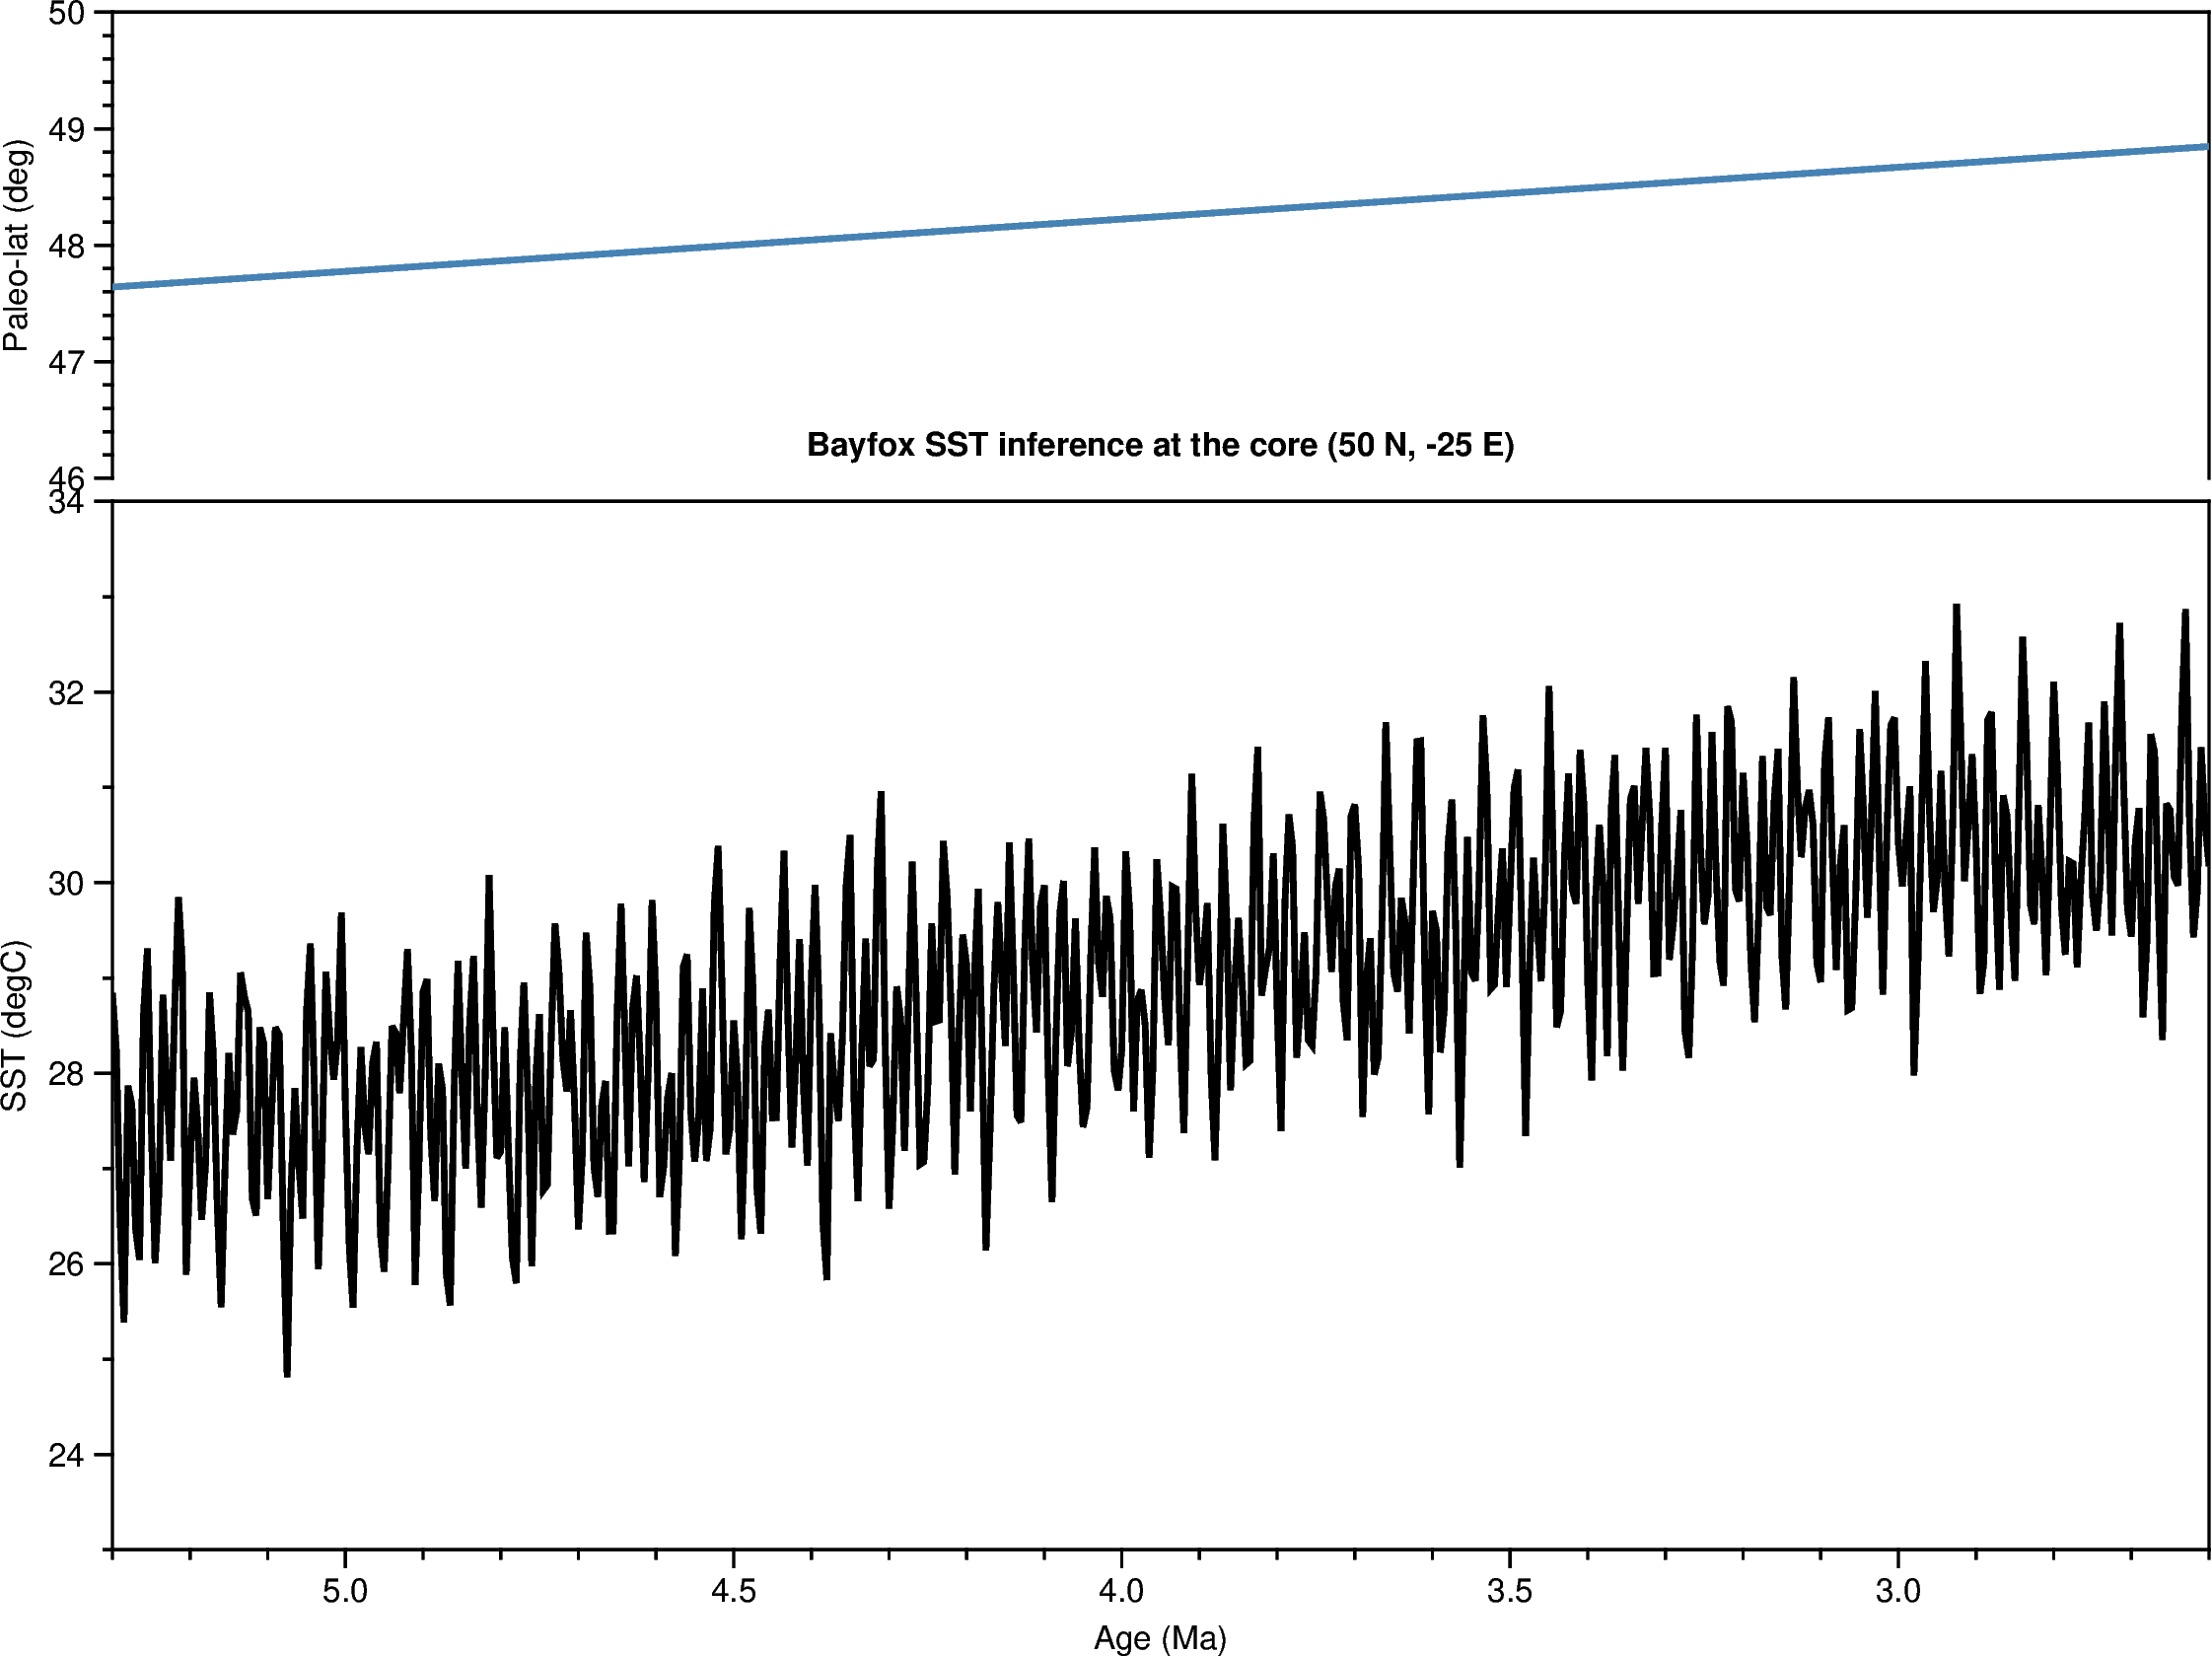

In [5]:
# Cell 4 — two-panel fan chart: SST fan + gplately-driven paleo-latitude
# Lower panel: bayfox-inferred SST envelope through the record (75% +
# 95% credible bands + median line). Upper panel: paleo-latitude of the
# core through the same age span, computed with gplately. This makes
# the SST interpretation explicit — the core was moving, so the
# inferred SST is not at a fixed position.

# Reconstruct core's paleo-latitude at every record age (gplately use #1)
_pmm   = PlateModelManager()
_model = _pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
_recon_for_chart = gplately.PlateReconstruction(
    rotation_model=_model.get_rotation_model(),
    topology_features=_model.get_topologies(),
    static_polygons=_model.get_static_polygons(),
)
_pts = gplately.Points(_recon_for_chart, [CORE_LON_LAT[0]], [CORE_LON_LAT[1]],
                       anchor_plate_id=ANCHOR_PLATE_ID)
_paleo_lats = []
for _t in rec["age_Ma"].values:
    _rl, _rla = _pts.reconstruct(float(_t),
                                 anchor_plate_id=ANCHOR_PLATE_ID,
                                 return_array=True)
    _paleo_lats.append(float(_rla[0]))
_paleo_lats = np.asarray(_paleo_lats)
print(f"  core paleo-latitude over record: "
      f"{_paleo_lats.min():.2f} - {_paleo_lats.max():.2f} deg")

fig = pygmt.Figure()
# --- Upper panel: paleo-latitude trajectory ---
_lat_lo = float(np.floor(_paleo_lats.min() - 1.0))
_lat_hi = float(np.ceil (_paleo_lats.max() + 1.0))
if _lat_hi - _lat_lo < 2.0:
    _mid = 0.5 * (_lat_lo + _lat_hi)
    _lat_lo, _lat_hi = _mid - 1.0, _mid + 1.0
fig.basemap(region=[rec['age_Ma'].min(), rec['age_Ma'].max(), _lat_lo, _lat_hi],
            projection="X-18c/4c",
            frame=["xaf", "yaf+lPaleo-lat (deg)", "Wrt"])
fig.plot(x=rec["age_Ma"], y=_paleo_lats, pen="1.5p,steelblue")

# Shift origin to leave room for the lower fan-chart panel
fig.shift_origin(yshift="-9.2c")

# --- Lower panel: SST fan chart ---
y_lo = float(np.floor(np.nanmin(lo95) - 1.0))
y_hi = float(np.ceil (np.nanmax(hi95) + 1.0))
fig.basemap(region=[rec['age_Ma'].min(), rec['age_Ma'].max(), y_lo, y_hi],
            projection="X-18c/9c",
            frame=["xaf+lAge (Ma)", "yaf+lSST (degC)",
                   f"WSrt+tBayfox SST inference at the core ({CORE_LON_LAT[1]:.0f} N, {CORE_LON_LAT[0]:.0f} E)"])
fig.plot(x=list(rec['age_Ma']) + list(rec['age_Ma'])[::-1],
         y=list(lo95) + list(hi95)[::-1],
         close=True, fill="gray85", pen="0.3p,gray70")
fig.plot(x=list(rec['age_Ma']) + list(rec['age_Ma'])[::-1],
         y=list(lo50) + list(hi50)[::-1],
         close=True, fill="gray65", pen="0.3p,gray55")
fig.plot(x=rec['age_Ma'], y=med, pen="1.5p,black")
fig.show(width=1000)
display(HTML('<div style="height:1cm"></div>'))


## 4. Inset paleo-Earth map: reconstructed core position at the target age

  loaded 478 foram occurrences from cenozoic_planktonic_forams.csv
  130 occurrences within ±5.0 Ma of 3.0 Ma
  reduced to 16 unique sites
  16 sites successfully reconstructed to 3.0 Ma
  bayfox-calibrated core paleo-position: (48.67 N, -24.37 E)
  bayfox SST at 3.0 Ma: median 30.41 degC (95% 30.41 - 30.41 degC)


makecpt [WARNING]: thermal is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).
makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


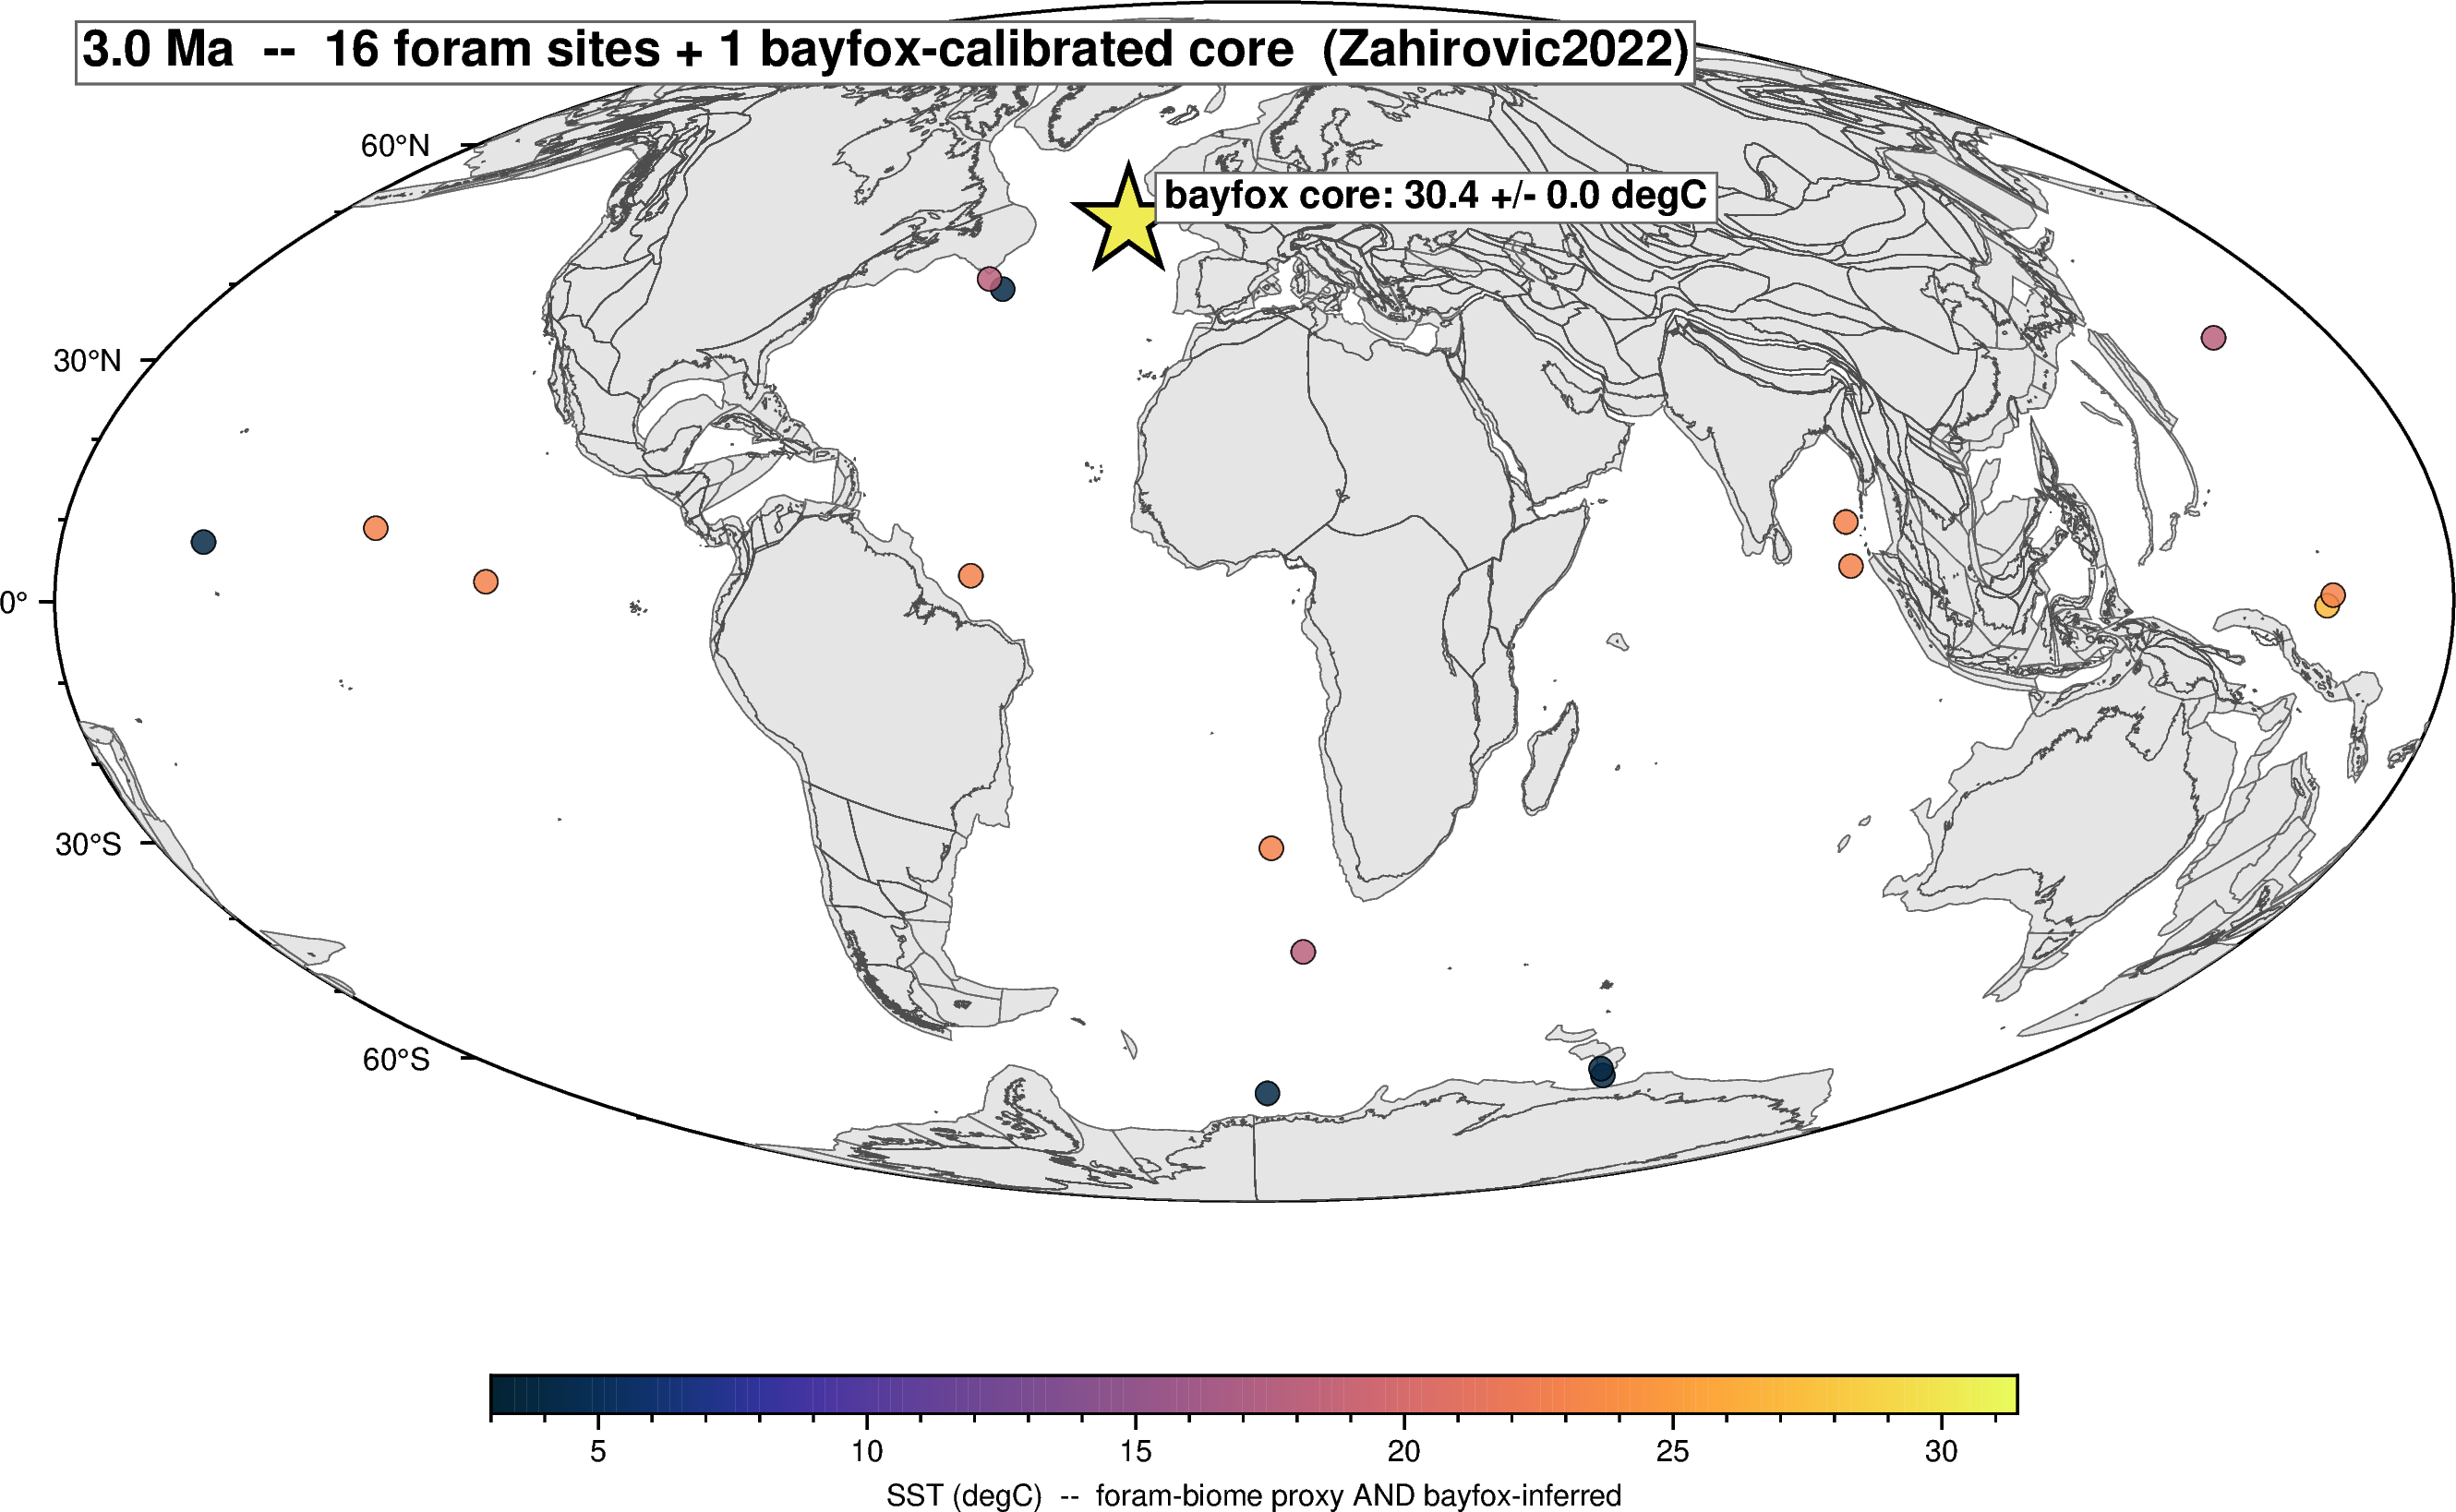

In [6]:
# Cell 5 — multi-site paleo-Earth map with the bayfox core highlighted
# Pull the Cenozoic foram site compilation (data/foraminifera_cenozoic),
# filter to sites with an active occurrence within FORAM_AGE_WINDOW_MA
# of TARGET_AGE_MA, reconstruct each to its paleo-position, and color
# the site by its biome category (a coarse but real SST regime proxy:
# tropical -> warm, temperate -> mid, polar -> cool).
# Overlay our bayfox-calibrated core as a star, color-coded by the
# precise inferred median SST at TARGET_AGE_MA.

# --- knob: width of the age window around TARGET_AGE_MA ---
FORAM_AGE_WINDOW_MA = 5.0

# --- biome -> representative SST (rough, for visual encoding only) ---
BIOME_SST = {
    "tropical":  27.0,
    "subtropical": 23.0,
    "temperate": 18.0,
    "subpolar":  10.0,
    "polar":      4.0,
}

pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# --- 1. Load the foram compilation and filter ---
FORAM_CSV = Path("data/foraminifera_cenozoic/cenozoic_planktonic_forams.csv")
forams = pd.read_csv(FORAM_CSV, comment="#")
print(f"  loaded {len(forams)} foram occurrences from {FORAM_CSV.name}")

# Filter to active sites near TARGET_AGE_MA
mask = (forams["age_ma"] - TARGET_AGE_MA).abs() <= FORAM_AGE_WINDOW_MA
near = forams.loc[mask].copy()
print(f"  {len(near)} occurrences within ±{FORAM_AGE_WINDOW_MA} Ma of {TARGET_AGE_MA} Ma")

# Reduce to one row per site (median age within the window)
sites = (near.groupby("site")
              .agg(lon=("lon", "first"),
                   lat=("lat", "first"),
                   age_ma=("age_ma", "median"),
                   biome=("biome", lambda s: s.mode().iat[0] if not s.empty else "unknown"))
              .reset_index())
sites["biome_sst"] = sites["biome"].map(BIOME_SST).fillna(15.0)
print(f"  reduced to {len(sites)} unique sites")

# --- 2. Reconstruct every site to its paleo-position at TARGET_AGE_MA ---
import numpy as _np
_pts = gplately.Points(recon, sites["lon"].to_numpy(),
                       sites["lat"].to_numpy(),
                       anchor_plate_id=ANCHOR_PLATE_ID)
_plate_ids = _np.atleast_1d(_pts.plate_id).astype(int)
_valid = _plate_ids > 0
if (~_valid).any():
    sites = sites.loc[_valid].reset_index(drop=True)
    _pts = gplately.Points(recon, sites["lon"].to_numpy(),
                           sites["lat"].to_numpy(),
                           anchor_plate_id=ANCHOR_PLATE_ID)
plons, plats = _pts.reconstruct(float(TARGET_AGE_MA),
                                 anchor_plate_id=ANCHOR_PLATE_ID,
                                 return_array=True)
sites["paleo_lon"] = plons
sites["paleo_lat"] = plats
sites = sites.dropna(subset=["paleo_lon", "paleo_lat"]).reset_index(drop=True)
print(f"  {len(sites)} sites successfully reconstructed to {TARGET_AGE_MA} Ma")

# --- 3. Compute the bayfox single-core SST + paleo-position ---
_idx = (rec["age_Ma"] - TARGET_AGE_MA).abs().idxmin()
target_med = float(med[_idx])
target_lo  = float(lo95[_idx])
target_hi  = float(hi95[_idx])
_core_pts  = gplately.Points(recon, [CORE_LON_LAT[0]], [CORE_LON_LAT[1]],
                              anchor_plate_id=ANCHOR_PLATE_ID)
_core_plon, _core_plat = _core_pts.reconstruct(float(TARGET_AGE_MA),
                                               anchor_plate_id=ANCHOR_PLATE_ID,
                                               return_array=True)
print(f"  bayfox-calibrated core paleo-position: "
      f"({float(_core_plat[0]):.2f} N, {float(_core_plon[0]):.2f} E)")
print(f"  bayfox SST at {TARGET_AGE_MA:.1f} Ma: "
      f"median {target_med:.2f} degC (95% {target_lo:.2f} - {target_hi:.2f} degC)")

# --- 4. Render the paleo-Earth map ---
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(TARGET_AGE_MA),

plot_engine=gplately.PygmtPlotEngine(),
)

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
try:
    gplot.plot_continents(fig, fill="gray90", pen="0.3p,gray40")
except Exception:
    pass
try:
    gplot.plot_coastlines(fig, pen="0.3p,gray30")
except Exception:
    pass

# Single CPT covers BOTH the biome proxy SST values AND the bayfox
# inferred SST, so the colour mapping is self-consistent.
_all_sst = list(sites["biome_sst"].values) + [target_med, target_lo, target_hi]
_sst_lo = float(min(_all_sst) - 1.0)
_sst_hi = float(max(_all_sst) + 1.0)
pygmt.makecpt(cmap="thermal",
              series=[_sst_lo, _sst_hi, (_sst_hi - _sst_lo) / 50.0],
              continuous=True, background="o")

# Foram sites: 0.20c circles, colored by biome SST proxy
fig.plot(x=sites["paleo_lon"].to_numpy(),
         y=sites["paleo_lat"].to_numpy(),
         style="c0.22c",
         fill=sites["biome_sst"].to_numpy(),
         cmap=True, pen="0.3p,black",
         transparency=15)

# Bayfox-calibrated core: large star with the precise inferred SST
fig.plot(x=_core_plon, y=_core_plat,
         style="a1.0c",
         fill=_np.array([target_med]),
         cmap=True, pen="1.2p,black")
fig.text(x=float(_core_plon[0]) + 6, y=float(_core_plat[0]) + 4,
         text=f"bayfox core: {target_med:.1f} +/- {(target_hi - target_lo)/2:.1f} degC",
         font="10p,Helvetica-Bold,black", justify="ML",
         fill="white", pen="0.5p,gray40",
         clearance="0.1c/0.06c+to")

fig.colorbar(frame=f"af+lSST (degC)  --  foram-biome proxy AND bayfox-inferred",
             position="JBC+w14c/0.35c+h+o0/1.6c")
fig.text(text=f"{TARGET_AGE_MA:.1f} Ma  --  {len(sites)} foram sites + 1 bayfox-calibrated core  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1300)

## What the figure shows

A Mollweide paleo-Earth map at `TARGET_AGE_MA` Ma with the δ18O proxy sites reconstructed to their paleo-positions and colour-coded by the **median posterior SST** from the Bayesian `bayfox (https://github.com/brews/bayfox)` calibration. The colourbar legend records the SST range in °C. The in-frame stamp annotates the target age and the median SST across all reconstructed sites.

What to read off:

- **Latitudinal SST gradient** — the colour pattern across the map should follow a recognisable tropics-warm / poles-cold structure for the target age.
- **The basin median SST** in the in-frame annotation is the headline number for that age — a single summary statistic for the proxy network's SST signal.
- **Posterior uncertainty** (not directly visible in colour, but propagated through to the colourbar choice) is what the Bayesian `bayfox` framework adds over a simple δ18O → SST inversion — it widens the SST estimate at sites with sparse calibration data.

Sweeping `TARGET_AGE_MA` across the Cenozoic and rebuilding this figure at each step animates the proxy-derived SST history through time, with each frame self-consistent in the Bayesian uncertainty sense.


## Extend this

- **Different species.** Set `SPECIES = "G_bulloides"` and re-run — the calibration coefficients change and the posterior SST shifts accordingly.
- **Multiple cores.** Loop over a directory of records and produce a posterior SST map for one specific time (e.g. mid-Pliocene), in the spirit of T37.
- **Cross-reference T37.** T37 plots assemblage composition at paleo-sites; T41 plots Bayesian SST at paleo-sites. Together they cover the two main proxy-data axes (composition vs geochemistry) in paleo-oceanography.

## References

- Malevich, S.B., Vetter, L. & Tierney, J.E. (2019). Bayesian regression model for Mg/Ca-based sea surface temperature estimates. *Paleoceanography and Paleoclimatology* 34, 446–460.
- Anand, P., Elderfield, H. & Conte, M.H. (2003). Calibration of Mg/Ca thermometry in planktonic foraminifera. *Paleoceanography* 18, 1050.
- Tierney, J.E. & Tingley, M.P. (2014). A Bayesian, spatially-varying calibration model for the TEX86 proxy. *Geochim. Cosmochim. Acta* 127, 83–106.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
